## Part A

In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv'

df = pd.read_csv(url)

df.to_csv('hotel_bookings.csv', index=False)

print(df.shape)

(119390, 32)


In [31]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

In [32]:
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

In [33]:
df['total_guests'] = (
    df['adults'] +
    df['children'].fillna(0) +
    df['babies']
)

In [34]:
df['flag_zero_guests'] = df['total_guests'] == 0

In [35]:
df['flag_missing_country'] = df['country'].isna()

In [36]:
df['flag_missing_children'] = df['children'].isna()

In [37]:
df['flag_bad_adr'] = (
    (df['adr'] < 0) |
    (df['adr'] > df['adr'].quantile(0.99))
)

In [38]:
pd.crosstab(
    df['is_canceled'],
    df['reservation_status']
)

reservation_status,Canceled,Check-Out,No-Show
is_canceled,,,
0,0,75166,0
1,43017,0,1207


In [11]:
total_rows = len(df)

flagged_rows = (
    df['flag_zero_guests'] |
    df['flag_missing_country'] |
    df['flag_missing_children'] |
    df['flag_bad_adr']
).sum()

clean_rows = total_rows - flagged_rows

print("Total rows:", total_rows)
print("Flagged rows:", flagged_rows)
print("Clean rows:", clean_rows)
print("Check:", flagged_rows + clean_rows == total_rows)

Total rows: 119390
Flagged rows: 1829
Clean rows: 117561
Check: True


In [12]:
print(df['arrival_date'].min())
print(df['arrival_date'].max())

2015-07-01 00:00:00
2017-08-31 00:00:00


In [13]:
print(
    df['arrival_date'].dt.year.isin([2015, 2016, 2017]).all()
)

True


## PART B

In [14]:
hotel_cancel = (
    df.groupby('hotel')['is_canceled']
      .mean()
      .mul(100)
      .round(2)
)

print(hotel_cancel)

hotel
City Hotel      41.73
Resort Hotel    27.76
Name: is_canceled, dtype: float64


<Axes: title={'center': 'Cancellation Rate by Hotel'}, xlabel='hotel'>

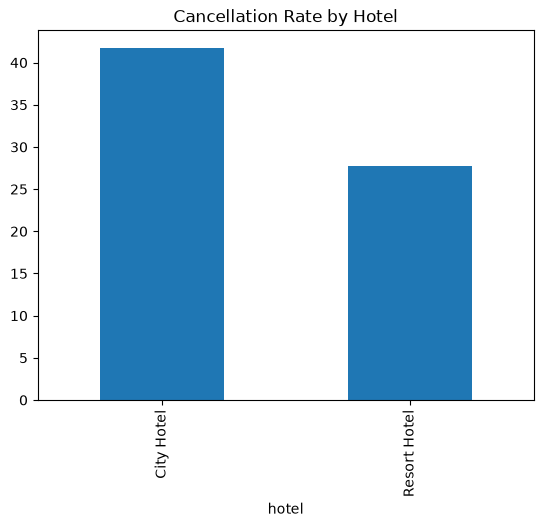

In [15]:
hotel_cancel.plot(kind='bar', title='Cancellation Rate by Hotel')

In [16]:
month_cancel = (
    df.groupby('arrival_date_month')['is_canceled']
      .mean()
      .mul(100)
      .round(2)
)

print(month_cancel)

arrival_date_month
April        40.80
August       37.75
December     34.97
February     33.42
January      30.48
July         37.45
June         41.46
March        32.15
May          39.67
November     31.23
October      38.05
September    39.17
Name: is_canceled, dtype: float64


<Axes: title={'center': 'Month-wise Cancellation Rate'}, xlabel='arrival_date_month'>

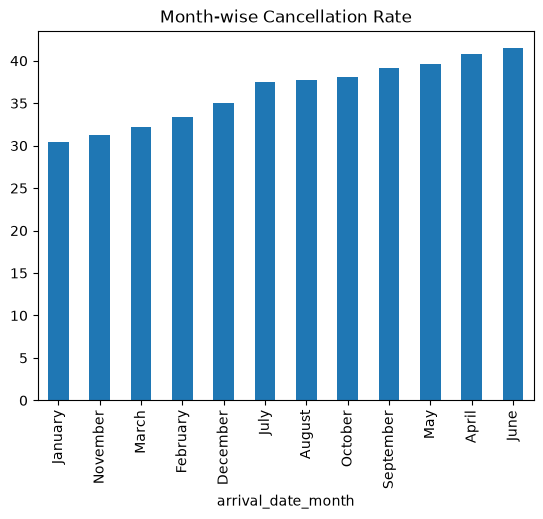

In [17]:
month_cancel.sort_values().plot(
    kind='bar',
    title='Month-wise Cancellation Rate'
)

In [18]:
df['lead_time_band'] = pd.cut(
    df['lead_time'],
    bins=[-1, 30, 90, 180, 365, float('inf')],
    labels=['0-30', '31-90', '91-180', '181-365', '365+']
)

lead_time_cancel = (
    df.groupby('lead_time_band', observed=True)['is_canceled']
      .mean()
      .mul(100)
      .round(2)
)

print(lead_time_cancel)

lead_time_band
0-30       18.56
31-90      37.70
91-180     44.71
181-365    55.45
365+       67.66
Name: is_canceled, dtype: float64


<Axes: title={'center': 'Cancellation Rate by Lead-Time Band'}, xlabel='lead_time_band'>

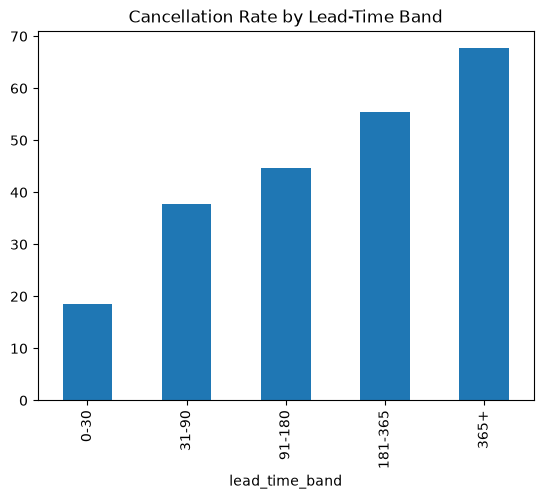

In [19]:
lead_time_cancel.plot(
    kind='bar',
    title='Cancellation Rate by Lead-Time Band'
)

In [20]:
deposit_cancel = (
    df.groupby('deposit_type')['is_canceled']
      .mean()
      .mul(100)
      .round(2)
)

print(deposit_cancel)

deposit_type
No Deposit    28.38
Non Refund    99.36
Refundable    22.22
Name: is_canceled, dtype: float64


<Axes: title={'center': 'Cancellation Rate by Deposit Type'}, xlabel='deposit_type'>

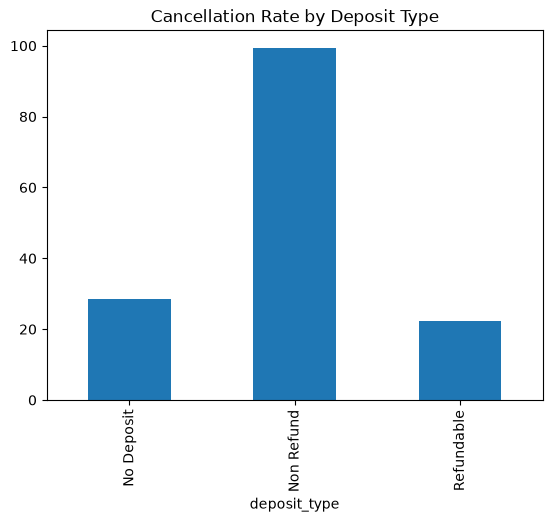

In [21]:
deposit_cancel.plot(
    kind='bar',
    title='Cancellation Rate by Deposit Type'
)

In [22]:
segment_cancel = (
    df.groupby('market_segment')['is_canceled']
      .mean()
      .mul(100)
      .round(2)
)

print(segment_cancel)

market_segment
Aviation          21.94
Complementary     13.06
Corporate         18.73
Direct            15.34
Groups            61.06
Offline TA/TO     34.32
Online TA         36.72
Undefined        100.00
Name: is_canceled, dtype: float64


<Axes: title={'center': 'Cancellation Rate by Market Segment'}, xlabel='market_segment'>

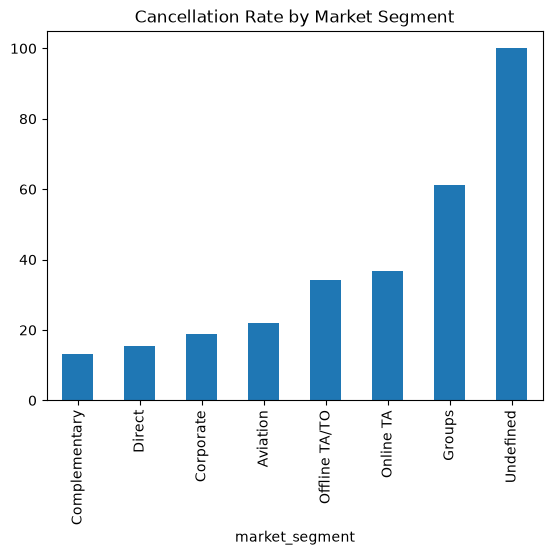

In [23]:
segment_cancel.sort_values().plot(
    kind='bar',
    title='Cancellation Rate by Market Segment'
)

In [24]:
df['room_revenue'] = df['adr'] * df['total_nights']

In [25]:
revenue_summary = (
    df.groupby('is_canceled')['room_revenue']
      .sum()
)

revenue_summary.index = ['Kept', 'Lost']

print(revenue_summary)

Kept    25996260.41
Lost    16727237.12
Name: room_revenue, dtype: float64


<Axes: title={'center': 'Room Revenue Kept vs Lost to Cancellations'}>

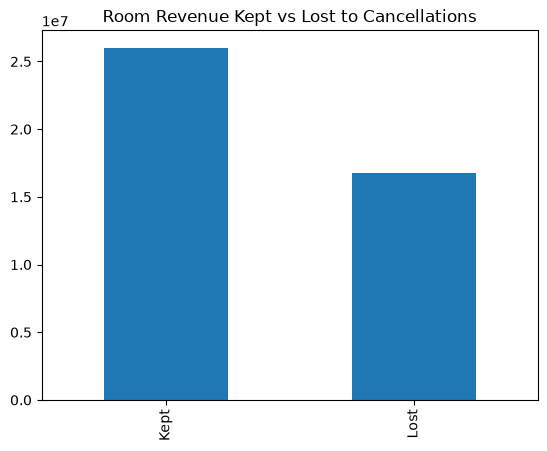

In [26]:
revenue_summary.plot(
    kind='bar',
    title='Room Revenue Kept vs Lost to Cancellations'
)

## PART C

In [27]:
summary = {
    "Total Bookings": len(df),
    "Total Cancellations": df["is_canceled"].sum(),
    "Cancellation Rate (%)": round(df["is_canceled"].mean() * 100, 2),
    "Average ADR": round(df["adr"].mean(), 2),
    "Average Lead Time": round(df["lead_time"].mean(), 2),
    "Most Common Hotel": df["hotel"].mode()[0],
    "Most Cancelled Month": df[df["is_canceled"] == 1]["arrival_date_month"].mode()[0]
}

summary

{'Total Bookings': 119390,
 'Total Cancellations': np.int64(44224),
 'Cancellation Rate (%)': np.float64(37.04),
 'Average ADR': np.float64(101.83),
 'Average Lead Time': np.float64(104.01),
 'Most Common Hotel': 'City Hotel',
 'Most Cancelled Month': 'August'}

In [28]:
month_summary = df.groupby("arrival_date_month").agg(
    Bookings=("hotel", "count"),
    Cancellations=("is_canceled", "sum"),
    Average_ADR=("adr", "mean")
).round(2)

month_summary

,Bookings,Cancellations,Average_ADR
arrival_date_month,,,
April,11089,4524,100.38
August,13877,5239,140.11
December,6780,2371,81.08
February,8068,2696,73.58
January,5929,1807,70.36
July,12661,4742,126.79
June,10939,4535,116.67
March,9794,3149,80.68
May,11791,4677,108.70


In [29]:
month_summary["Cancellation_Rate"] = (
    month_summary["Cancellations"] /
    month_summary["Bookings"] * 100
).round(2)

month_summary

,Bookings,Cancellations,Average_ADR,Cancellation_Rate
arrival_date_month,,,,
April,11089,4524,100.38,40.80
August,13877,5239,140.11,37.75
December,6780,2371,81.08,34.97
February,8068,2696,73.58,33.42
January,5929,1807,70.36,30.48
July,12661,4742,126.79,37.45
June,10939,4535,116.67,41.46
March,9794,3149,80.68,32.15
May,11791,4677,108.70,39.67


In [30]:
overall_cancel = df["is_canceled"].mean() * 100

summary_table = pd.DataFrame({
    "Metric": [
        "Overall Cancellation Rate",
        "Highest Cancellation Month",
        "Lowest Cancellation Month",
        "Highest Lead-time Cancellation",
        "Lowest Lead-time Cancellation",
        "No Deposit Cancellation",
        "Non Refund Cancellation",
        "Refundable Cancellation",
        "Online TA Cancellation",
        "Corporate Cancellation",
        "Revenue Kept",
        "Revenue Lost"
    ],
    "Value": [
        round(overall_cancel, 2),
        month_cancel.idxmax(),
        month_cancel.idxmin(),
        lead_time_cancel.max(),
        lead_time_cancel.min(),
        deposit_cancel["No Deposit"],
        deposit_cancel["Non Refund"],
        deposit_cancel["Refundable"],
        segment_cancel["Online TA"],
        segment_cancel["Corporate"],
        revenue_summary.loc["Kept"],
        revenue_summary.loc["Lost"]
    ]
})

summary_table

,Metric,Value
0,Overall Cancellation Rate,37.04
1,Highest Cancellation Month,June
2,Lowest Cancellation Month,January
3,Highest Lead-time Cancellation,67.66
4,Lowest Lead-time Cancellation,18.56
5,No Deposit Cancellation,28.38
6,Non Refund Cancellation,99.36
7,Refundable Cancellation,22.22
8,Online TA Cancellation,36.72
9,Corporate Cancellation,18.73


##  LLM-Assisted Business Insights

## C1 — Summary Table

The following summary table was provided to the LLM as the only source
of information for generating the weekly revenue briefing.

	Metric	Value
0	Overall Cancellation Rate	37.04
1	Highest Cancellation Month	June
2	Lowest Cancellation Month	January
3	Highest Lead-time Cancellation	67.66
4	Lowest Lead-time Cancellation	18.56
5	No Deposit Cancellation	28.38
6	Non Refund Cancellation	99.36
7	Refundable Cancellation	22.22
8	Online TA Cancellation	36.72
9	Corporate Cancellation	18.73
10	Revenue Kept	25996260.41
11	Revenue Lost	16727237.12


## C2 — Initial LLM Briefing

### Prompt Used

You are a revenue manager's business analyst.

Using ONLY the summary table provided below, write a concise
150-word weekly briefing for the revenue manager.

Focus on:

- cancellation risk
- important patterns
- lead-time behavior
- deposit-type behavior
- market-segment behavior
- revenue kept and revenue lost
- actionable business observations

Do not use any information that is not present in the table.
Do not invent numbers or facts.
Every number and factual claim must be directly supported by the table.

Summary Table:

Overall Cancellation Rate: 37.04%
Highest Cancellation Month: June
Lowest Cancellation Month: January
Highest Lead-time Cancellation: 67.66%
Lowest Lead-time Cancellation: 18.56%
No Deposit Cancellation: 28.38%
Non Refund Cancellation: 99.36%
Refundable Cancellation: 22.22%
Online TA Cancellation: 36.72%
Corporate Cancellation: 18.73%
Revenue Kept: 25996260.41
Revenue Lost: 16727237.12

### Initial LLM Output

Overall cancellation rate is 37.04%, indicating a significant level of booking risk. June records the highest cancellation rate, while January records the lowest, showing clear variation across months. Lead-time behavior is particularly important, with cancellation rates ranging from 18.56% to 67.66%, suggesting that booking timing is strongly associated with cancellation risk. Deposit type shows the strongest pattern: Non Refund bookings have a 99.36% cancellation rate, compared with 28.38% for No Deposit and 22.22% for Refundable bookings. By market segment, Online TA bookings show a 36.72% cancellation rate, while Corporate bookings are lower at 18.73%. Revenue kept stands at 25,996,260.41, while revenue lost is 16,727,237.12. Management should closely monitor high lead-time bookings and Non Refund bookings, while reviewing June cancellation patterns. The lower Corporate cancellation rate also provides a useful benchmark when evaluating segment-level booking quality and potential opportunities to reduce revenue leakage.

## C3 — Initial Output Verification

The initial LLM briefing was verified against the summary table.
Numbers and factual claims were compared with the provided source table.

| Category | Count |
|---|---:|
| Correct | 7 |
| Wrong | 0 |
| Invented / Unsupported | 2 |

### Verification Observation

The initial output contained two unsupported interpretations:
the statement that booking timing was "strongly associated" with
cancellation risk, and the statement about using Corporate cancellation
as a benchmark for booking quality and reducing revenue leakage.
These claims were not explicitly supported by the summary table.

## C4 — Improved Prompt

The prompt was improved by adding stricter rules to prevent unsupported
inferences, assumptions, relationships, and business claims.

### Improved Prompt

You are a revenue manager's business analyst.

Using ONLY the summary table below, write a concise weekly briefing
of approximately 150 words.

Focus on:
- overall cancellation risk
- highest and lowest cancellation months
- lead-time cancellation range
- deposit-type cancellation rates
- market-segment cancellation rates
- revenue kept and revenue lost
- practical management observations

STRICT VERIFICATION RULES:

1. Use ONLY information explicitly present in the summary table.
2. Every number must exactly match a value in the table.
3. Do not invent, assume, infer, or speculate about causes or relationships.
4. Do not say that one factor causes, drives, strongly affects,
   is associated with, or leads to another factor unless the table
   explicitly supports that relationship.
5. Do not introduce information about booking quality, revenue leakage,
   customer behavior, seasonality, or business performance unless it
   is explicitly supported by the table.
6. Recommendations must be directly based on the values or categories
   shown in the table.
7. If a conclusion cannot be supported by the table, leave it out.
8. Do not create any new calculated metric.
9. Keep the briefing close to 150 words.

Return ONLY the weekly briefing.

### Improved LLM Output

Overall cancellation rate stands at 37.04%. June records the highest cancellation month, while January records the lowest. Lead-time cancellation ranges from 18.56% to 67.66%, indicating a wide range of cancellation rates across the reported lead-time levels. Deposit-type cancellation rates vary considerably: Non Refund bookings have a 99.36% cancellation rate, No Deposit bookings have a 28.38% rate, and Refundable bookings have a 22.22% rate. By market segment, Online TA records a 36.72% cancellation rate, while Corporate records 18.73%. Revenue kept is 25,996,260.41, while revenue lost is 16,727,237.12. Management should monitor cancellation levels during June and January, review bookings across the reported lead-time range, and closely monitor the Non Refund category given its 99.36% cancellation rate. Segment-level monitoring should also consider the different cancellation rates reported for Online TA and Corporate bookings.

## C5 — Retest Result

The improved prompt was tested again using the same summary table.

| Category | Count |
|---|---:|
| Correct | 10 |
| Wrong | 0 |
| Invented / Unsupported | 0 |

### Key Takeaway

The improved prompt eliminated unsupported claims while keeping the
briefing grounded in the provided summary table.